# 02 · Model Comparison
We compare **7 classic models** on two feature sets, then combine the best ones in an ensemble.

*This notebook is a quick walkthrough (single split, default threshold 0.5). The full pipeline with 5-fold CV, threshold tuning and stacking is `src/train.py`; its results are loaded at the end.*

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); pd.set_option("display.max_colwidth", 80)

## 1. Features

In [2]:
from src.preprocess import load_data
from src.features import meta_features, NUMERIC_FEATURES
from src.config import CATEGORICAL_FIELDS
df = load_data()
X = meta_features(df); X["text"] = df["text"]; y = df["fraudulent"].values
X.drop(columns="text").describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
has_company_logo,17880.0,0.80,0.40,0.0,1.00,1.00,1.00,1.00
has_questions,17880.0,0.49,0.50,0.0,0.00,0.00,1.00,1.00
telecommuting,17880.0,0.04,0.20,0.0,0.00,0.00,0.00,1.00
salary_given,17880.0,0.16,0.37,0.0,0.00,0.00,0.00,1.00
company_profile_missing,17880.0,0.19,0.39,0.0,0.00,0.00,0.00,1.00
log_word_count,17880.0,5.77,0.66,1.1,5.46,5.89,6.23,7.66
money_words,17880.0,0.27,0.48,0.0,0.00,0.00,0.36,5.41
urgency_words,17880.0,0.23,0.34,0.0,0.00,0.00,0.34,8.33
contact_app_words,17880.0,0.00,0.07,0.0,0.00,0.00,0.00,3.00
url_count,17880.0,0.62,1.25,0.0,0.00,0.00,1.00,16.00


In [3]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(len(X_tr), "train /", len(X_te), "test | fake in test:", y_te.sum())

14304 train / 3576 test | fake in test: 173


## 2. Define the models
**Text models** use TF-IDF of the post. **Metadata models** use the 17 engineered features (scaled + one-hot).

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

tfidf = lambda: ColumnTransformer([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9,
                                    max_features=50000, sublinear_tf=True, stop_words="english"), "text")])
meta = lambda: ColumnTransformer([("num", StandardScaler(), NUMERIC_FEATURES),
                                  ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FIELDS)])
pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()
models = {
    "Naive Bayes": Pipeline([("prep", tfidf()), ("clf", MultinomialNB(alpha=0.05))]),
    "Logistic Regression": Pipeline([("prep", tfidf()), ("clf", LogisticRegression(
        C=10, class_weight="balanced", max_iter=3000, solver="liblinear"))]),
    "Linear SVM": Pipeline([("prep", tfidf()), ("clf", CalibratedClassifierCV(
        LinearSVC(C=0.5, class_weight="balanced"), cv=3))]),
    "KNN": Pipeline([("prep", meta()), ("clf", KNeighborsClassifier(n_neighbors=15, weights="distance"))]),
    "Decision Tree": Pipeline([("prep", meta()), ("clf", DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=5, class_weight="balanced", random_state=42))]),
    "Random Forest": Pipeline([("prep", meta()), ("clf", RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=42))]),
    "XGBoost": Pipeline([("prep", meta()), ("clf", XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_w, n_jobs=-1, random_state=42))]),
}

## 3. Train and evaluate

In [5]:
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, accuracy_score)
rows, probs = [], {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_te)[:, 1]; probs[name] = p; pred = (p >= 0.5).astype(int)
    rows.append({"model": name, "accuracy": accuracy_score(y_te, pred), "precision": precision_score(y_te, pred),
                 "recall": recall_score(y_te, pred), "f1": f1_score(y_te, pred),
                 "roc_auc": roc_auc_score(y_te, p), "pr_auc": average_precision_score(y_te, p)})
res = pd.DataFrame(rows).set_index("model").round(3); res

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Naive Bayes,0.989,0.934,0.821,0.874,0.992,0.921
Logistic Regression,0.993,0.951,0.896,0.923,0.993,0.957
Linear SVM,0.992,0.968,0.867,0.915,0.993,0.955
KNN,0.970,0.770,0.543,0.637,0.947,0.747
Decision Tree,0.904,0.311,0.815,0.450,0.880,0.503
Random Forest,0.970,0.697,0.665,0.680,0.964,0.774
XGBoost,0.954,0.517,0.792,0.626,0.949,0.758


Note how **accuracy is above 0.90 for every model**, even when recall is poor. That's why we focus on F1 and PR-AUC.

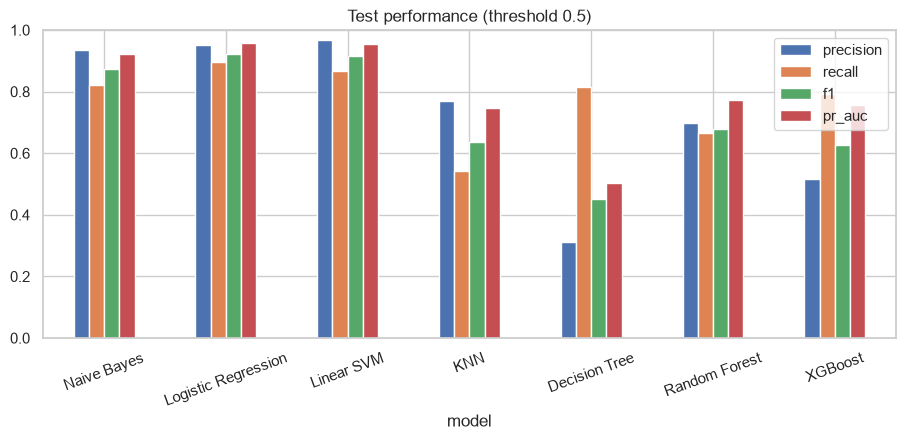

In [6]:
res[["precision", "recall", "f1", "pr_auc"]].plot.bar(figsize=(11, 4), ylim=(0, 1),
                                                     title="Test performance (threshold 0.5)")
plt.xticks(rotation=20); plt.show()

## 4. Simple soft-voting ensemble
Average the probability of the best text model and the best metadata model.

In [7]:
p_vote = (probs["Logistic Regression"] + probs["Random Forest"]) / 2
print("Soft voting  F1:", round(f1_score(y_te, (p_vote >= 0.5).astype(int)), 3),
      " PR-AUC:", round(average_precision_score(y_te, p_vote), 3))

Soft voting  F1: 0.908  PR-AUC: 0.957


## 5. Interpreting the models

In [8]:
lr = models["Logistic Regression"]
vocab = lr.named_steps["prep"].named_transformers_["tfidf"].get_feature_names_out()
coef = lr.named_steps["clf"].coef_[0]; order = np.argsort(coef)
pd.DataFrame({"fake words": vocab[order[::-1][:15]], "coef_fake": coef[order[::-1][:15]].round(2),
              "real words": vocab[order[:15]], "coef_real": coef[order[:15]].round(2)})

,fake words,coef_fake,real words,coef_real
0,link urltoken,8.10,english,-4.55
1,using link,7.43,companies,-4.30
2,apply using,6.49,software,-4.08
3,phonetoken,5.53,clients,-3.60
4,line requirements,5.46,team,-3.60
5,money,5.10,digital,-3.60
6,hospital,5.00,growing,-3.54
7,receptionist,4.99,recruitment,-3.51
8,accion,4.97,client,-3.48
9,link,4.87,new,-3.27


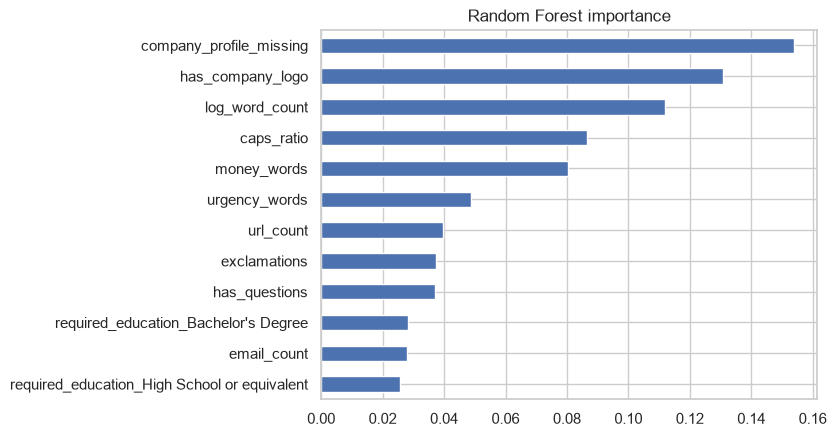

In [9]:
rf = models["Random Forest"]
names = [n.split("__", 1)[1] for n in rf.named_steps["prep"].get_feature_names_out()]
pd.Series(rf.named_steps["clf"].feature_importances_, index=names).sort_values().tail(12).plot.barh(
    title="Random Forest importance"); plt.show()

## 6. Full pipeline results (`python -m src.train`)
5-fold CV out-of-fold predictions → tuned thresholds → **stacking** meta-learner. The test set is used once.

In [10]:
m = json.loads((ROOT / "reports/metrics.json").read_text())
full = pd.DataFrame({n: {"group": r["group"], "cv_pr_auc": r["cv"]["pr_auc"],
                         **{k: r["test"][k] for k in ["threshold", "precision", "recall", "f1", "roc_auc", "pr_auc"]}}
                     for n, r in m["models"].items()}).T
print("Final model:", m["final_model"], "=", m["best_text"], "+", m["best_meta"]); full

Final model: Stacking = Logistic Regression + Random Forest


,group,cv_pr_auc,threshold,precision,recall,f1,roc_auc,pr_auc
Naive Bayes,text,0.860662,0.2924,0.850575,0.855491,0.853026,0.992258,0.921
Logistic Regression,text,0.91524,0.5167,0.956522,0.890173,0.922156,0.993457,0.956853
Linear SVM,text,0.914226,0.412,0.962264,0.884393,0.921687,0.993007,0.954573
KNN,meta,0.695353,0.3526,0.674847,0.635838,0.654762,0.94733,0.747187
Decision Tree,meta,0.418955,0.907,0.400685,0.676301,0.503226,0.880055,0.502602
Random Forest,meta,0.713183,0.5232,0.700637,0.635838,0.666667,0.963533,0.773561
XGBoost,meta,0.685342,0.7651,0.680233,0.676301,0.678261,0.949472,0.758332
Soft Voting,ensemble,0.914337,0.4595,0.95625,0.884393,0.918919,0.994802,0.956798
Stacking,ensemble,0.921081,0.4719,0.9625,0.890173,0.924925,0.995232,0.961008


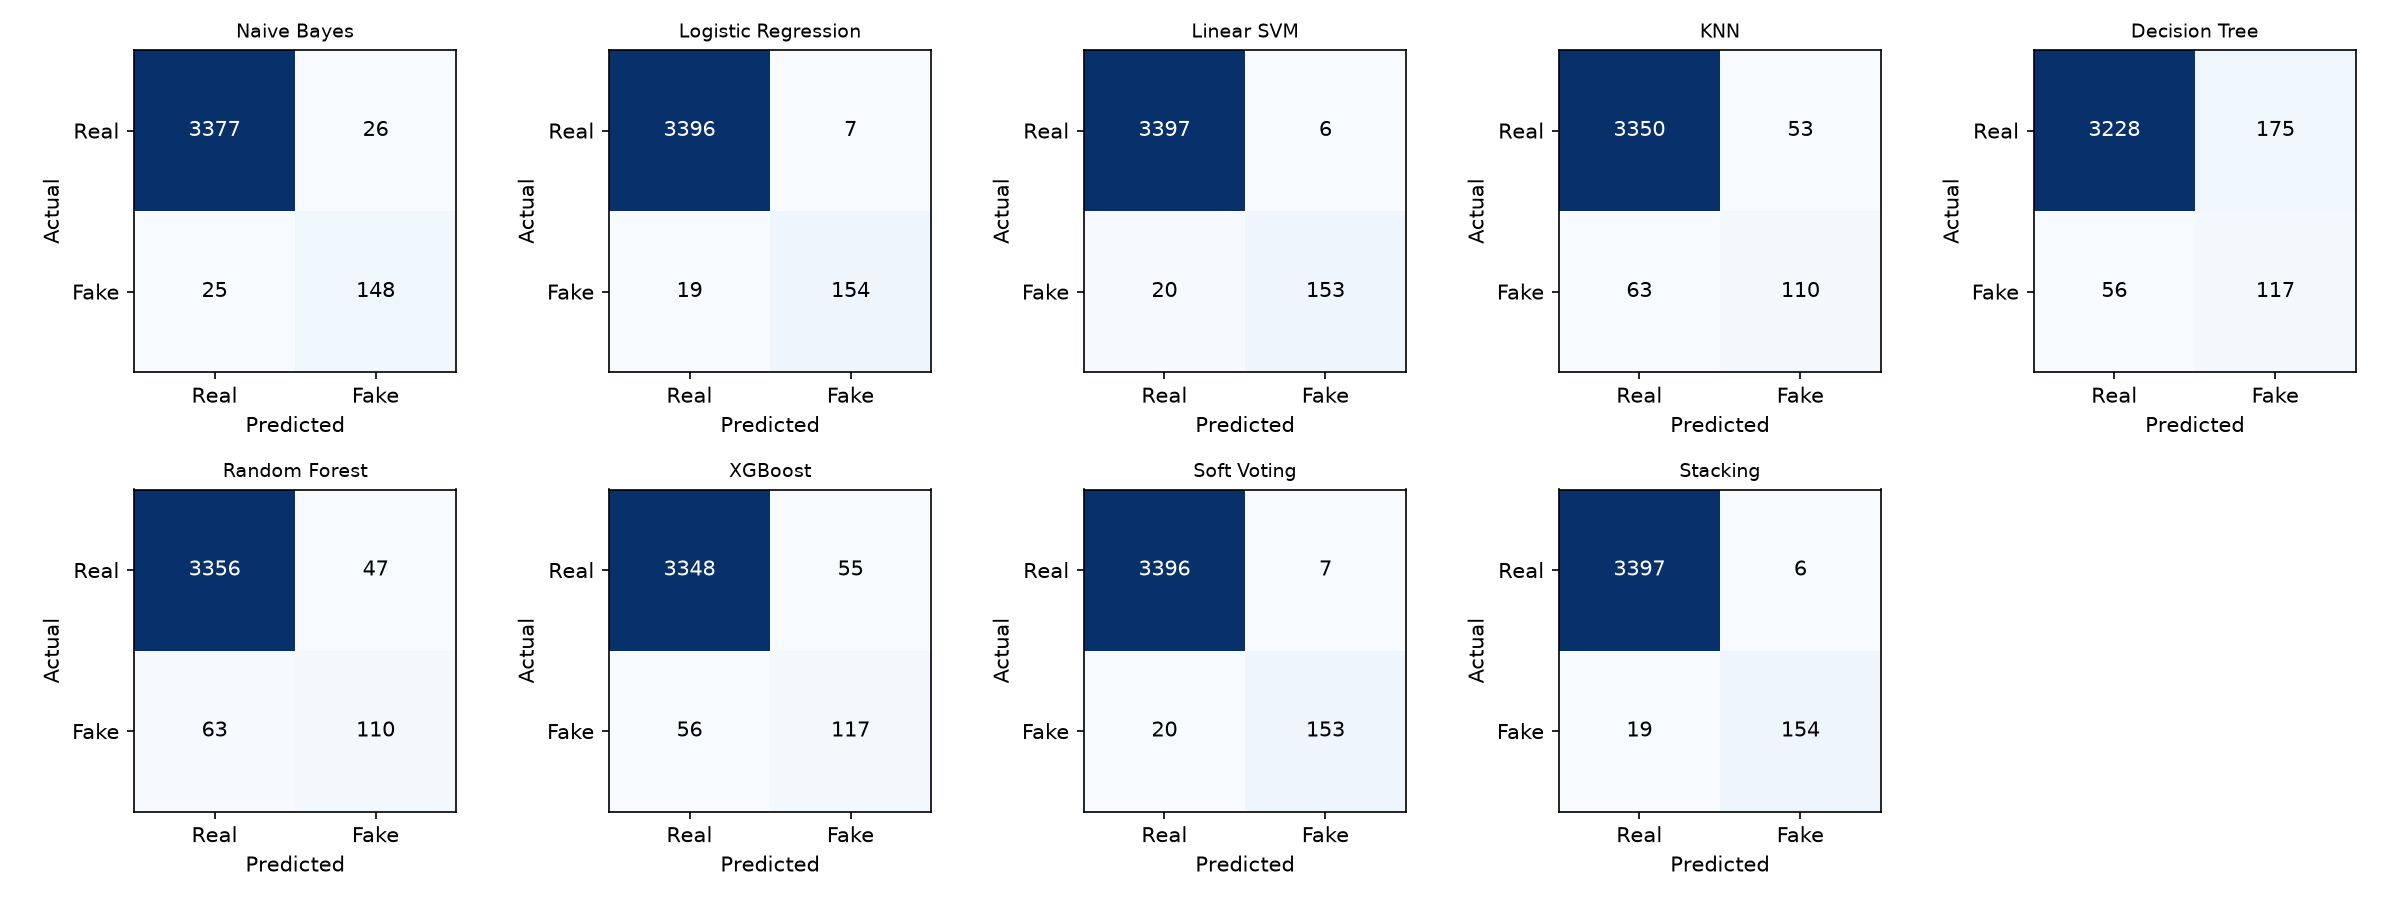

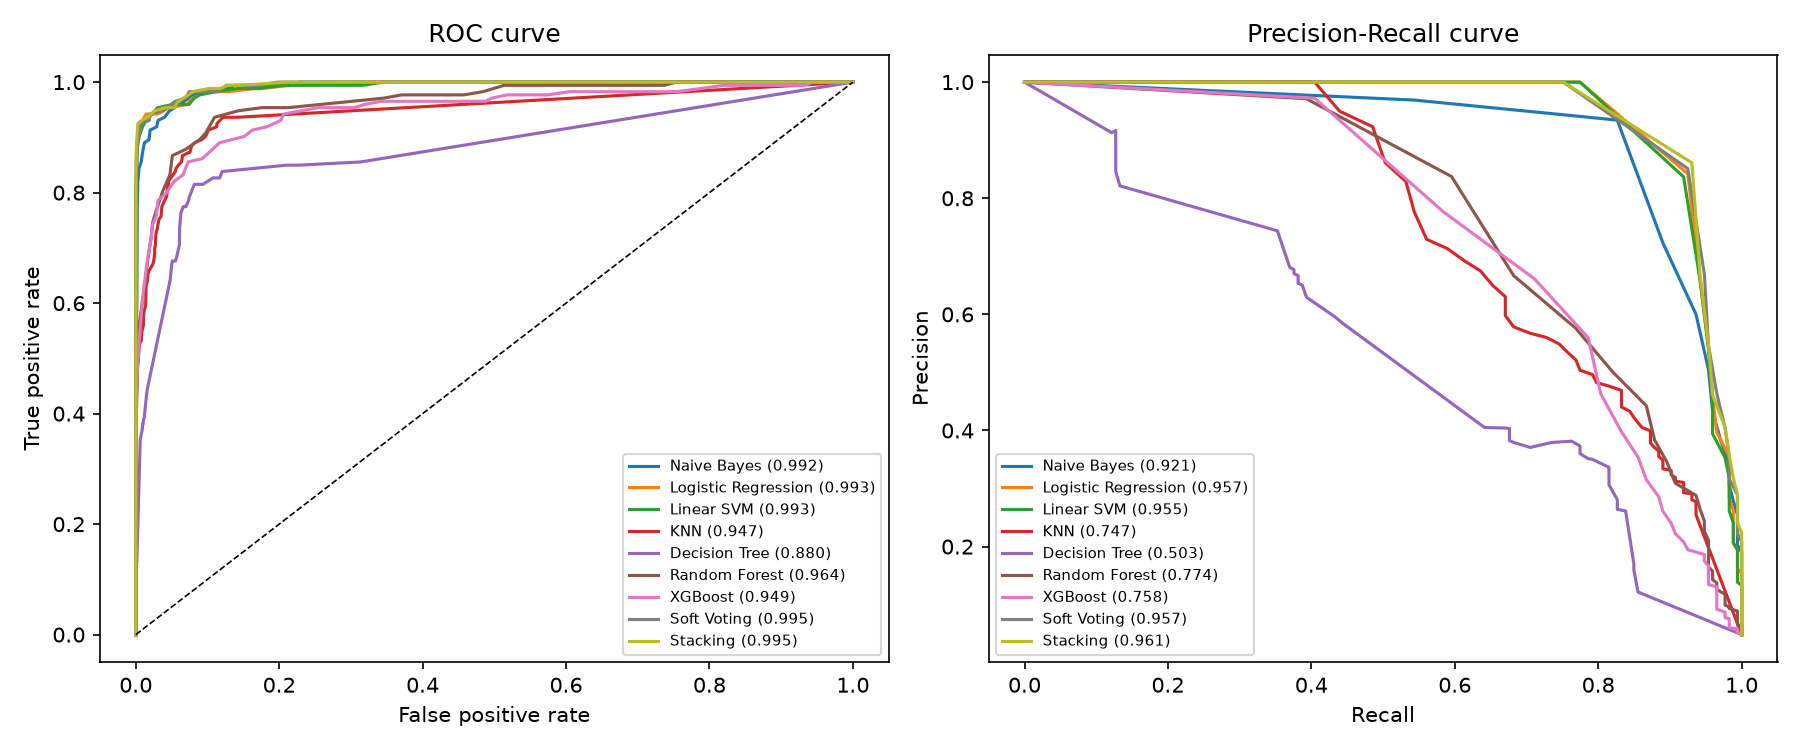

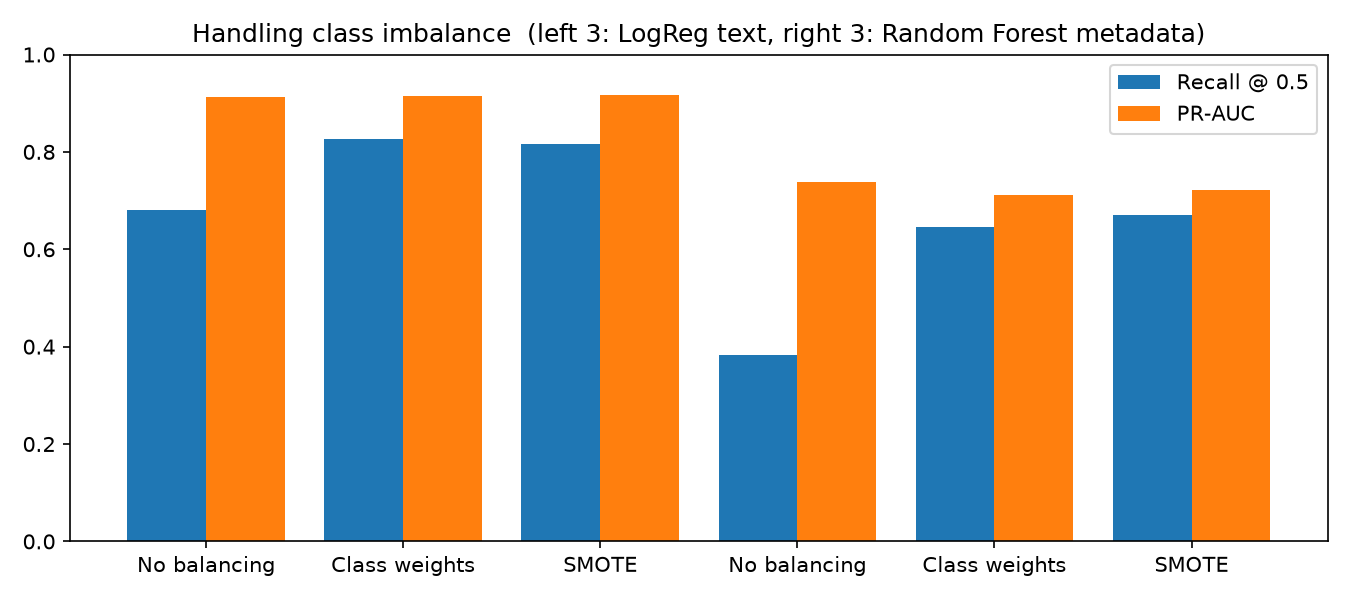

In [11]:
from IPython.display import Image, display
for f in ["confusion_matrices.png", "roc_pr_curves.png", "imbalance_experiment.png"]:
    display(Image(str(ROOT / "reports/figures" / f)))

In [12]:
pd.DataFrame(m["imbalance_experiment"]).round(3)

,model,strategy,recall@0.5,f1@0.5,pr_auc
0,Logistic Regression (text),No balancing,0.680,0.798,0.913
1,Logistic Regression (text),Class weights,0.827,0.860,0.915
2,Logistic Regression (text),SMOTE,0.817,0.861,0.916
3,Random Forest (metadata),No balancing,0.382,0.546,0.738
4,Random Forest (metadata),Class weights,0.645,0.631,0.711
5,Random Forest (metadata),SMOTE,0.671,0.650,0.723


## Conclusions
- Linear models on TF-IDF (Logistic Regression, Linear SVM) are the strongest single models.
- Tree ensembles (Random Forest, XGBoost) beat a single Decision Tree on the metadata features.
- **Stacking** the text and metadata models gives the best overall result.
- Class weights and SMOTE raise recall at the default threshold. Threshold tuning matters as much as the choice of model.